# yfinance Library Assignment  

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [ ]:
def download_historical_data(symbol,start_date,end_date) :
    ticker=yf.Ticker(symbol) 
    historical_data=ticker.history(start=start_date,end=end_date,interval='1d') 
    return historical_data
download_historical_data(symbol='AAPL',start_date="2024-01-01",end_date="2025-01-01")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-01-02 00:00:00-05:00,185.055258,186.330827,181.831752,183.562164,82488700,0.0,0.0
2024-01-03 00:00:00-05:00,182.158081,183.799505,181.376915,182.187744,58414500,0.0,0.0
2024-01-04 00:00:00-05:00,180.111221,181.040702,178.855446,179.873917,71983600,0.0,0.0
2024-01-05 00:00:00-05:00,179.953046,180.714417,178.153410,179.152100,62379700,0.0,0.0
2024-01-08 00:00:00-05:00,180.051901,183.522623,179.468508,183.483063,59144500,0.0,0.0
...,...,...,...,...,...,...,...
2024-12-24 00:00:00-05:00,253.868050,256.570768,253.669307,256.560852,23234700,0.0,0.0
2024-12-26 00:00:00-05:00,256.550862,258.448740,255.994420,257.375580,27237100,0.0,0.0
2024-12-27 00:00:00-05:00,256.193177,257.057679,251.453470,253.967407,42355300,0.0,0.0


### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [7]:
def plot_closing_price(data, symbol):
    plt.figure(figsize=(10, 5))
    plt.plot(data['Close'])
    plt.title(symbol + ' Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.show()

### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

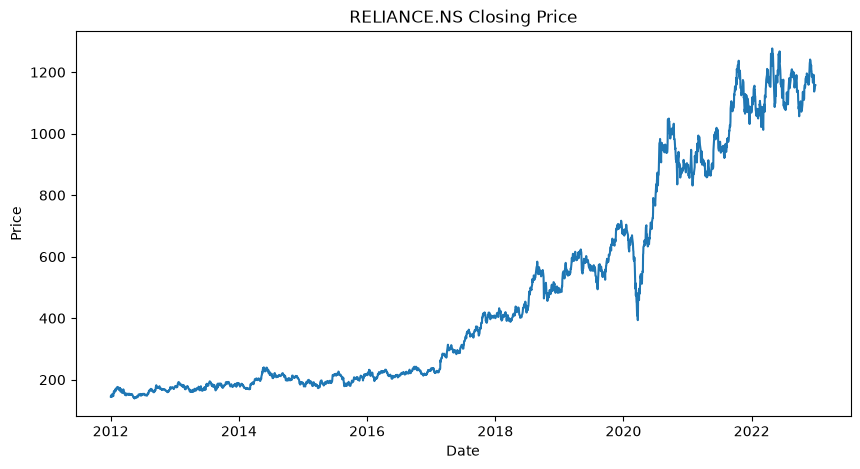

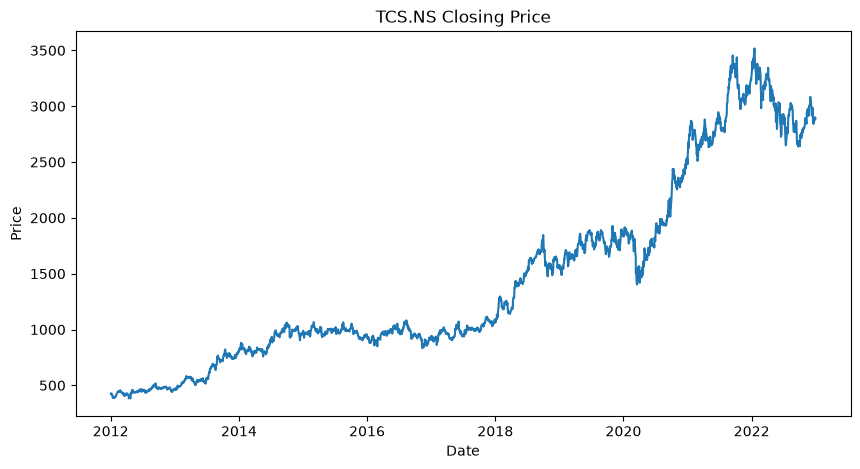

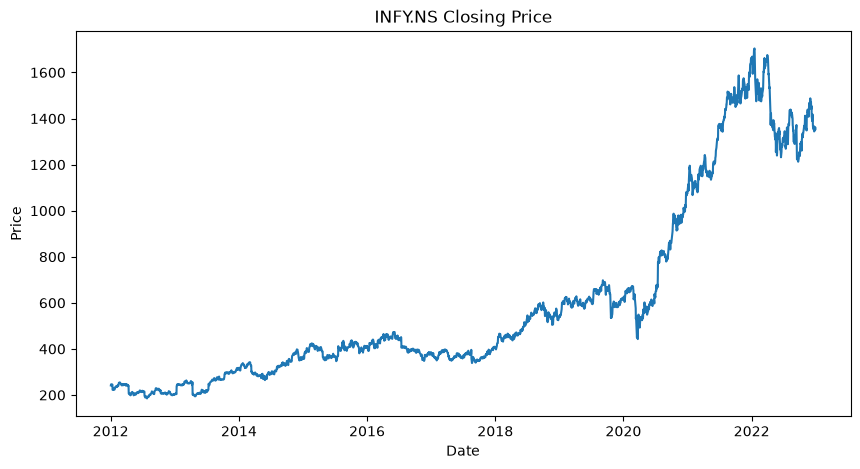

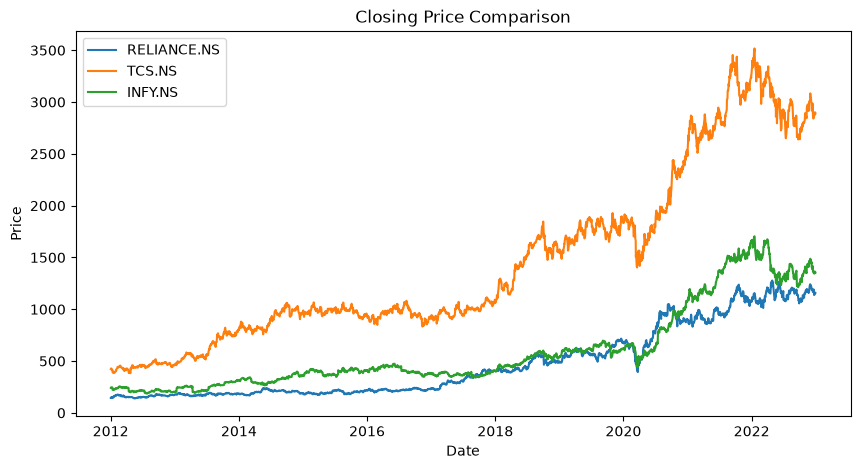

In [8]:
stock1 = 'RELIANCE.NS'
stock2 = 'TCS.NS'
stock3 = 'INFY.NS'

start_date = '2012-01-01'
end_date = '2022-12-31'

data1 = download_historical_data(stock1, start_date, end_date)
data2 = download_historical_data(stock2, start_date, end_date)
data3 = download_historical_data(stock3, start_date, end_date)

plot_closing_price(data1, stock1)
plot_closing_price(data2, stock2)
plot_closing_price(data3, stock3)

plt.figure(figsize=(10, 5))
plt.plot(data1['Close'], label=stock1)
plt.plot(data2['Close'], label=stock2)
plt.plot(data3['Close'], label=stock3)
plt.title('Closing Price Comparison')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

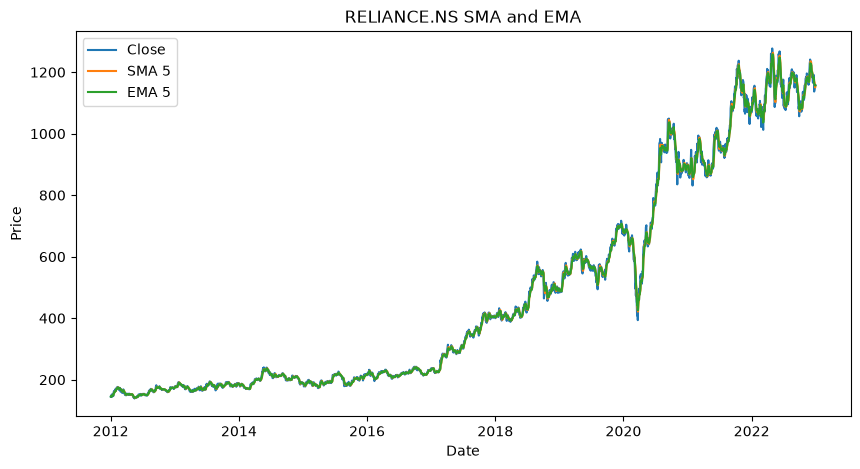

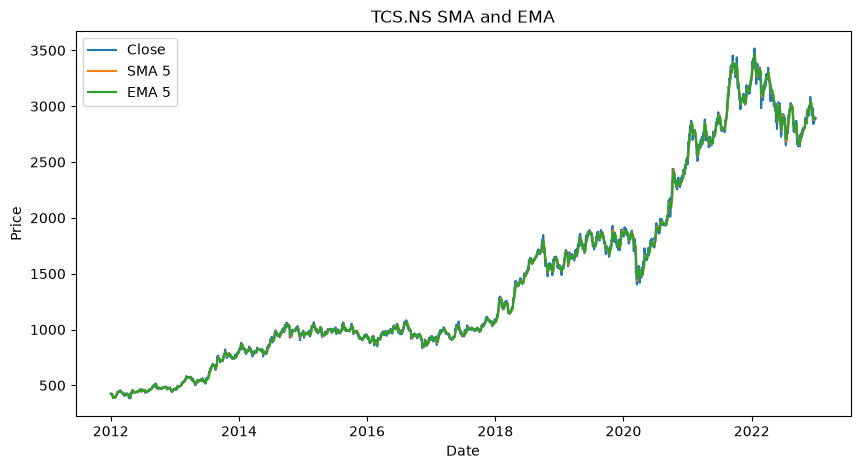

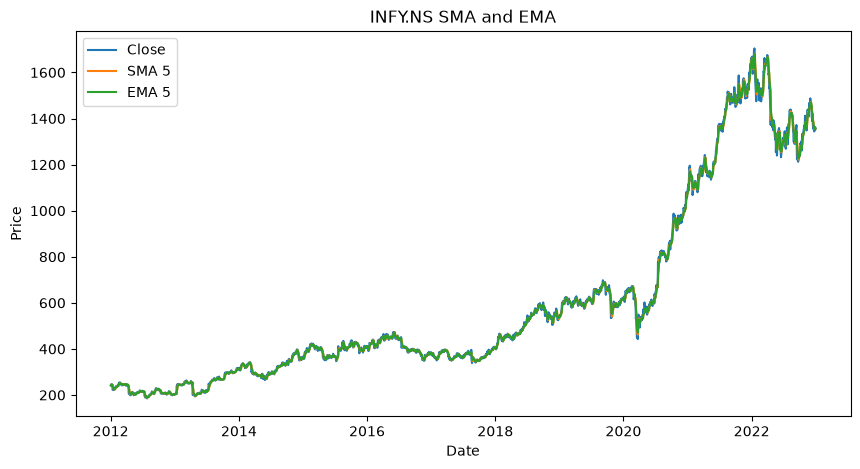

In [9]:
data1['SMA5'] = data1['Close'].rolling(5).mean()
data1['EMA5'] = data1['Close'].ewm(span=5, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data1['Close'], label='Close')
plt.plot(data1['SMA5'], label='SMA 5')
plt.plot(data1['EMA5'], label='EMA 5')
plt.title(stock1 + ' SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

data2['SMA5'] = data2['Close'].rolling(5).mean()
data2['EMA5'] = data2['Close'].ewm(span=5, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data2['Close'], label='Close')
plt.plot(data2['SMA5'], label='SMA 5')
plt.plot(data2['EMA5'], label='EMA 5')
plt.title(stock2 + ' SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

data3['SMA5'] = data3['Close'].rolling(5).mean()
data3['EMA5'] = data3['Close'].ewm(span=5, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data3['Close'], label='Close')
plt.plot(data3['SMA5'], label='SMA 5')
plt.plot(data3['EMA5'], label='EMA 5')
plt.title(stock3 + ' SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

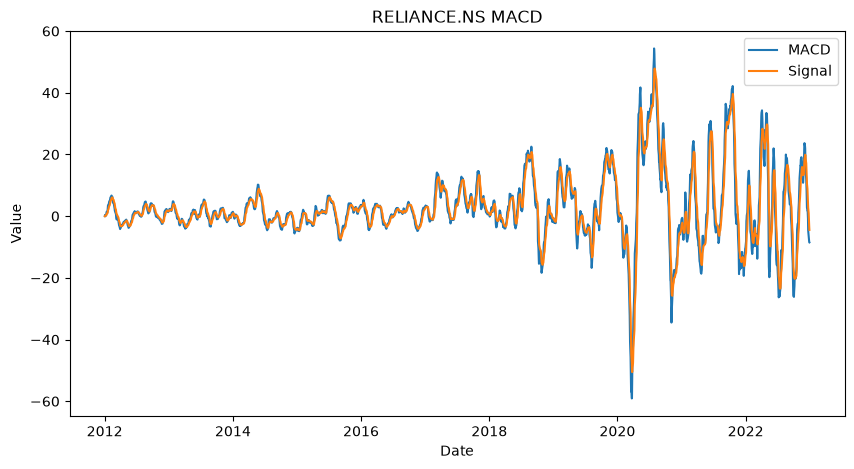

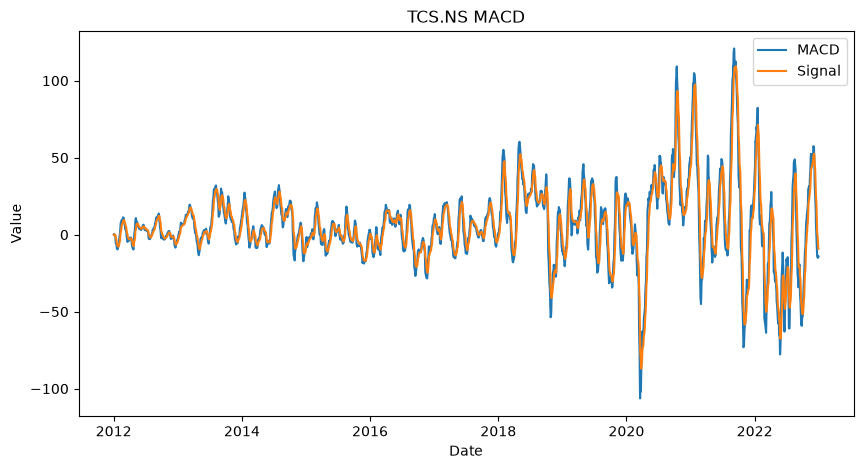

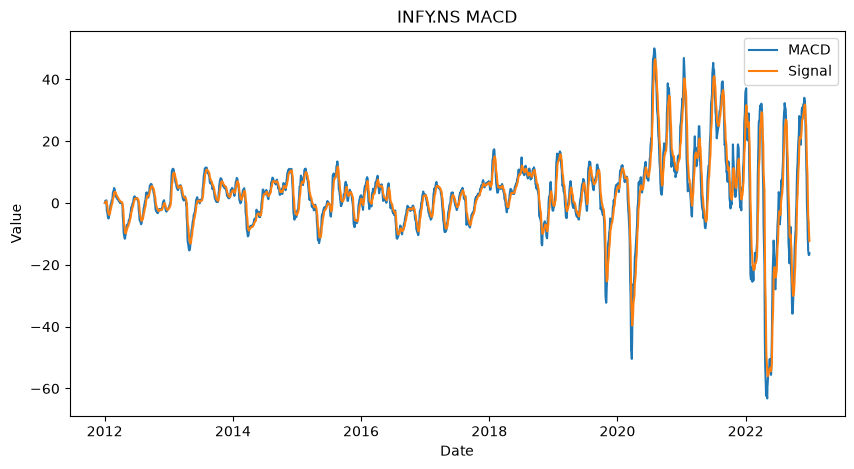

In [10]:
data1['EMA12'] = data1['Close'].ewm(span=12, adjust=False).mean()
data1['EMA26'] = data1['Close'].ewm(span=26, adjust=False).mean()
data1['MACD'] = data1['EMA12'] - data1['EMA26']
data1['Signal'] = data1['MACD'].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data1['MACD'], label='MACD')
plt.plot(data1['Signal'], label='Signal')
plt.title(stock1 + ' MACD')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

data2['EMA12'] = data2['Close'].ewm(span=12, adjust=False).mean()
data2['EMA26'] = data2['Close'].ewm(span=26, adjust=False).mean()
data2['MACD'] = data2['EMA12'] - data2['EMA26']
data2['Signal'] = data2['MACD'].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data2['MACD'], label='MACD')
plt.plot(data2['Signal'], label='Signal')
plt.title(stock2 + ' MACD')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

data3['EMA12'] = data3['Close'].ewm(span=12, adjust=False).mean()
data3['EMA26'] = data3['Close'].ewm(span=26, adjust=False).mean()
data3['MACD'] = data3['EMA12'] - data3['EMA26']
data3['Signal'] = data3['MACD'].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(10, 5))
plt.plot(data3['MACD'], label='MACD')
plt.plot(data3['Signal'], label='Signal')
plt.title(stock3 + ' MACD')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

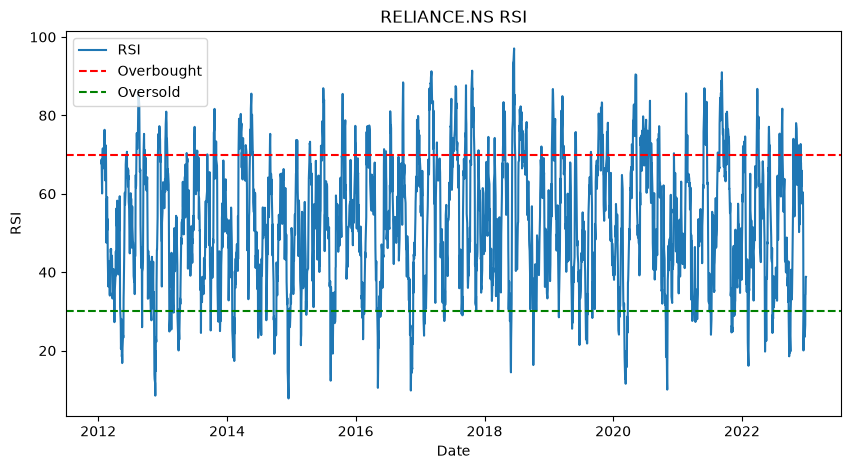

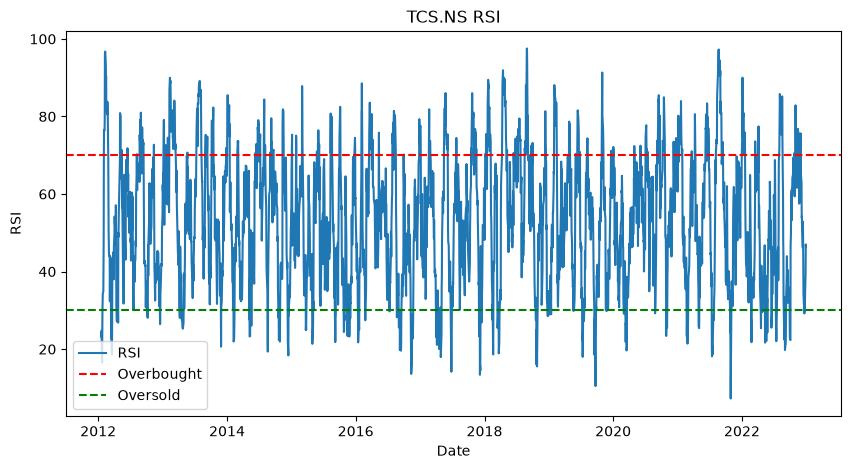

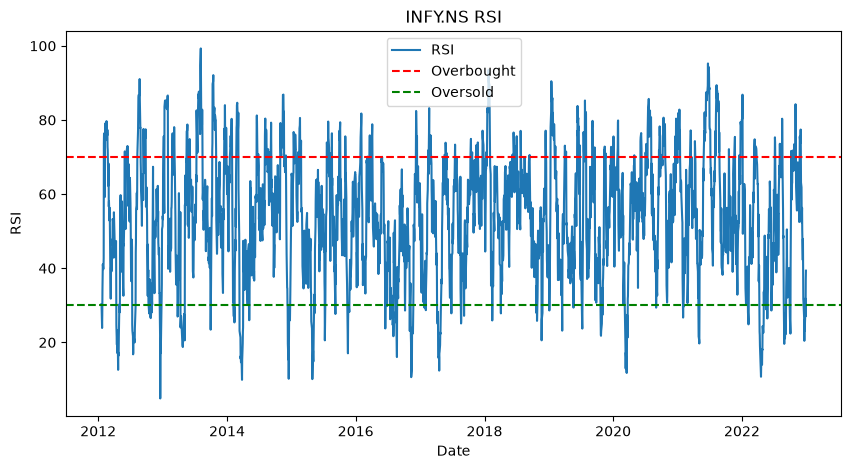

In [11]:
delta1 = data1['Close'].diff()
gain1 = delta1.where(delta1 > 0, 0)
loss1 = -delta1.where(delta1 < 0, 0)
avg_gain1 = gain1.rolling(14).mean()
avg_loss1 = loss1.rolling(14).mean()
rs1 = avg_gain1 / avg_loss1
data1['RSI'] = 100 - (100 / (1 + rs1))

plt.figure(figsize=(10, 5))
plt.plot(data1['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title(stock1 + ' RSI')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

delta2 = data2['Close'].diff()
gain2 = delta2.where(delta2 > 0, 0)
loss2 = -delta2.where(delta2 < 0, 0)
avg_gain2 = gain2.rolling(14).mean()
avg_loss2 = loss2.rolling(14).mean()
rs2 = avg_gain2 / avg_loss2
data2['RSI'] = 100 - (100 / (1 + rs2))

plt.figure(figsize=(10, 5))
plt.plot(data2['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title(stock2 + ' RSI')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

delta3 = data3['Close'].diff()
gain3 = delta3.where(delta3 > 0, 0)
loss3 = -delta3.where(delta3 < 0, 0)
avg_gain3 = gain3.rolling(14).mean()
avg_loss3 = loss3.rolling(14).mean()
rs3 = avg_gain3 / avg_loss3
data3['RSI'] = 100 - (100 / (1 + rs3))

plt.figure(figsize=(10, 5))
plt.plot(data3['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title(stock3 + ' RSI')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

### Summarize your analysis

In [12]:
"""
All three stocks moved upward overall from 2012 to 2022, with TCS and INFY rising more
steadily than RELIANCE, which had bigger ups and downs.

The EMA line reacts faster to price changes than the SMA line for all three stocks.

When the MACD line crosses above the Signal line, the stock is usually about to go up.
When it crosses below, the stock is usually about to go down. These crossovers match the
ups and downs seen in the price charts.

RSI went above 70 (overbought) during strong rallies and below 30 (oversold) during sharp
falls like the 2020 crash, for all three stocks.

Overall, RELIANCE was more volatile but also grew more in absolute terms, while TCS and
INFY were steadier.
 """

'\nAll three stocks moved upward overall from 2012 to 2022, with TCS and INFY rising more\nsteadily than RELIANCE, which had bigger ups and downs.\n\nThe EMA line reacts faster to price changes than the SMA line for all three stocks.\n\nWhen the MACD line crosses above the Signal line, the stock is usually about to go up.\nWhen it crosses below, the stock is usually about to go down. These crossovers match the\nups and downs seen in the price charts.\n\nRSI went above 70 (overbought) during strong rallies and below 30 (oversold) during sharp\nfalls like the 2020 crash, for all three stocks.\n\nOverall, RELIANCE was more volatile but also grew more in absolute terms, while TCS and\nINFY were steadier.\n '